## Problem 4.14 — Strawberry Jam

Strawberries contain about **15 wt% solids** and **85 wt% water**. To make strawberry jam, crushed strawberries and sugar are mixed in a **45:55 mass ratio**, and the mixture is heated to evaporate water until the residue contains **one-third water by mass**.

**(a)** Draw and label a flowchart of this process.

**(b)** Do the degree-of-freedom analysis and show that the system has zero degrees of freedom (i.e., the number of unknown process variables equals the number of equations relating them). If you have too many unknowns, think about what you might have forgotten to do.

**(c)** Calculate how many pounds of strawberries are needed to make a pound of jam.

**(d)** Making a pound of jam is something you could accomplish in your own kitchen (or maybe even a dorm room). However, a typical manufacturing line for jam might produce **1500 lbm/h**. List technical and economic factors you would have to take into account as you scaled up this process from your kitchen to a commercial operation.

![problem4.14](../../../artifacts/strawberry_4_14_env.png)

4 variables unknown: $m_M, m_W, m_G, m_A$

2 components $\to$ water and solids = 2 independent material balances

1 independent relationship: $\frac{m_M}{m_A}=\frac{45}{55}=k$

1 degree of freedom

- Hypotheses:
  - no accumulation
  - no reaction inside the heater

material balance for water: $0.85m_M = m_W + 1/3m_G$

material balance for solids: $0.15m_M + m_A = 2/3 m_G$

we know that: $m_M = km_A$

$$0.85(km_A) = m_W + 1/3m_G$$

$$0.15(km_A) + m_A = 2/3 m_G$$

suppose we want to calculate the flows based on $m_G$, we can reorganize this system into:

$$0.85k m_A-m_W=1/3m_G$$

$$(0.15k+1)m_A=2/3 m_G$$

or, in linear system notation:

\begin{bmatrix}0.85k & 1 \\ (0.15k+1) & 0\end{bmatrix}\begin{bmatrix}m_A \\ m_W\end{bmatrix}=\begin{bmatrix}1/3m_G \\ 2/3m_G\end{bmatrix}

In [1]:
import numpy as np

def calculate_stream_based_on_jam_mass(
        m_jam: float,
        k: float = 45./55.,
        strawberry_water_content: float = 0.85,
        jam_water_content: float = 1/3
) -> dict:
    """
    performs the material balance of jam heater to calculate all streams

    Args:
        m_jam (float): desired mass of jam produced
        k (float, optional): strawberry to sugar ratio. Defaults to 45./55..
        strawberry_water_content (float, optional): strawberry water conten. Defaults to 0.85.
        jam_water_content (float, optional): jam water content. Defaults to 1/3.

    Returns:
        dict: material balance metadata
    """
    strawberry_solids = 1 - strawberry_water_content

    # build the linear system
    A = np.array([
        [strawberry_water_content * k, -1],
        [strawberry_solids * k + 1, 0]
    ])

    b = np.array([
        jam_water_content * m_jam,
        (1 - jam_water_content) * m_jam
    ])

    # solve the linear system
    sugar_mass, water_mass = np.linalg.solve(A, b)

    strawberry_mass = sugar_mass * k

    return {
        "strawberry_mass": strawberry_mass,
        "sugar_mass": sugar_mass,
        "water_mass": water_mass,
        "jam_mass": m_jam
    }

In [2]:
# Example usage
desired_jam_mass = 1000  # kg
result = calculate_stream_based_on_jam_mass(desired_jam_mass)
print(f"To produce {desired_jam_mass} kg of jam, you need:")
print(f"- {result['strawberry_mass']:.2f} kg of strawberries")
print(f"- {result['sugar_mass']:.2f} kg of sugar")
print(f"- {result['water_mass']:.2f} kg of water evaporated")

To produce 1000 kg of jam, you need:
- 485.83 kg of strawberries
- 593.79 kg of sugar
- 79.62 kg of water evaporated


## Problem 4.6 — Partial Evaporation of an Acetone–Water Mixture

A liquid mixture of acetone and water contains **35 mole% acetone**. The mixture is to be partially evaporated to produce a vapor that is **75 mole% acetone** and leave a residual liquid that is **18.7 mole% acetone**.

### (a)

Suppose the process is to be carried out **continuously and at steady state** with a feed rate of **10.0 kmol/h**. Let $\dot{n}_v$ and $\dot{n}_l$ be the flow rates of the vapor and liquid product streams, respectively.

Draw and label a process flowchart, then write and solve balances on **total moles** and on **acetone** to determine the values of $\dot{n}_v$ and $\dot{n}_l$.

For each balance, state which terms in the general balance equation

$$
\text{accumulation}
=
\text{input}
+
\text{generation}
-
\text{output}
-
\text{consumption}
$$

can be discarded and why.

### (b)

Now suppose the process is to be carried out in a **closed container** that initially contains **10.0 kmol** of the liquid mixture. Let $n_v$ and $n_l$ be the moles of final vapor and liquid phases, respectively.

Draw and label a process flowchart, then write and solve **integral balances** on total moles and on acetone.

For each balance, state which terms of the general balance equation can be discarded and why.

### (c)

Returning to the continuous process, suppose the vaporization unit is built and started and the product stream flow rates and compositions are measured.

The measured acetone content of the vapor stream is **75 mole% acetone**, and the product stream flow rates have the values calculated in Part (a). However, the liquid product stream is found to contain **22.3 mole% acetone**.

It is possible that there is an error in the measured composition of the liquid stream, but give **at least five other reasons** for the discrepancy.

*Think about assumptions made in obtaining the solution of Part (a).*

In [3]:
# import the material balance module
from src.material_balances import StreamFactory

# Create a factory with shared component list
factory = StreamFactory(
    ['Water', 'Acetone'],
    default_flow_type='kmol/h',
    molar_masses={'Water': 18.015, 'Acetone': 58.08},
)

# Create streams using positional compositions
feed = factory.add_stream('F-101', [0.65, 0.35], flow_rate=10)
vapor = factory.add_stream('V-101', [None, 0.75], direction='output')
liquid = factory.add_stream('L-101', [None, 0.187], direction='output')

# Build and solve the process unit
evaporator = factory.build_process_unit('H-101')
balances = evaporator.solve_material_balances()
evaporator.print_report()
balances




Process unit report: H-101
Material balance basis: molar

Input streams:
  F-101: total flow = 10 kmol/h
    Water: molar fraction = 0.65, component flow = 6.5 kmol/h
    Acetone: molar fraction = 0.35, component flow = 3.5 kmol/h
    derived mass flow = 320.378
    derived molar flow = 10

Output streams:
  V-101: total flow = 2.8952 kmol/h
    Water: molar fraction = 0.25, component flow = 0.723801 kmol/h
    Acetone: molar fraction = 0.75, component flow = 2.1714 kmol/h
    derived mass flow = 139.154
    derived molar flow = 2.8952
  L-101: total flow = 7.1048 kmol/h
    Water: molar fraction = 0.813, component flow = 5.7762 kmol/h
    Acetone: molar fraction = 0.187, component flow = 1.3286 kmol/h
    derived mass flow = 181.223
    derived molar flow = 7.1048

Molar balance checks:
  Acetone: input = 3.5, output = 3.5, residual = 0 [PASS]
  Water: input = 6.5, output = 6.5, residual = 0 [PASS]


F-101       V-101       L-101
variable                  component                                    
mass_flow_rate                       320.377500  139.154374  181.223126
molar_flow_rate                       10.000000    2.895204    7.104796
component_mass_flow_rate  Acetone    203.280000  126.115098   77.164902
                          Water      117.097500   13.039276  104.058224
component_molar_flow_rate Acetone      3.500000    2.171403    1.328597
                          Water        6.500000    0.723801    5.776199
mass_fraction             Acetone      0.634501    0.906296    0.425801
                          Water        0.365499    0.093704    0.574199
mole_fraction             Acetone      0.350000    0.750000    0.187000
                          Water        0.650000    0.250000    0.813000

In [4]:
# lets solve the jam production problem
factory = StreamFactory(
    component_names=['Solids','Water'],
    default_flow_type='kg/h'
)

# add streams
factory.add_stream('Strawberry', [0.15, 0.85])
factory.add_stream('Sugar', [1, 0])
factory.add_stream('Evaporated Water', [0., 1.], direction='output')
factory.add_stream('Jam', [2/3, 1/3], direction='output', flow_rate=1000)

# add ratio constraint
factory.add_ratio(stream1='Strawberry', stream2='Sugar', target_ratio=45/55)

# build process unit
evaporator = factory.build_process_unit('Jam Evaporator')

# calculate material balances
try:
    evaporator.solve_material_balances()
    evaporator.print_report()
except:
    evaporator.report_degrees_of_freedom()
    evaporator.suggest_missing_information()



Process unit report: Jam Evaporator
Material balance basis: mass
Molar-basis results unavailable for streams containing: Solids, Water (molar mass not supplied).

Input streams:
  Strawberry: total flow = 485.83 kg/h
    Solids: mass fraction = 0.15, component flow = 72.8745 kg/h
    Water: mass fraction = 0.85, component flow = 412.955 kg/h
    derived mass flow = 485.83
  Sugar: total flow = 593.792 kg/h
    Solids: mass fraction = 1, component flow = 593.792 kg/h
    Water: mass fraction = 0, component flow = 0 kg/h
    derived mass flow = 593.792

Output streams:
  Evaporated Water: total flow = 79.6221 kg/h
    Solids: mass fraction = 0, component flow = 0 kg/h
    Water: mass fraction = 1, component flow = 79.6221 kg/h
    derived mass flow = 79.6221
  Jam: total flow = 1000 kg/h
    Solids: mass fraction = 0.666667, component flow = 666.667 kg/h
    Water: mass fraction = 0.333333, component flow = 333.333 kg/h
    derived mass flow = 1000

Mass balance checks:
  Solids: input 

## Problem 4.13 — Checking the Consistency of Stream Analyses

A process is carried out in which a mixture containing **25.0 wt% methanol**, **42.5 wt% ethanol**, and the balance **water** is separated into two fractions.

A technician draws and analyzes samples of both product streams and reports that:

- one stream contains **39.8 wt% methanol** and **31.5 wt% ethanol**
- the other stream contains **19.7 wt% methanol** and **41.2 wt% ethanol**

You examine the reported figures and tell the technician that they must be wrong and that the stream analyses should be carried out again.

In [5]:
# check mass balances - assuming 1 kg/h of input
factory = StreamFactory(
    component_names=['Methanol','Ethanol', 'Water'],
    default_flow_type='kg/h',
    molar_masses={
        'Methanol': 32.04,
        'Ethanol': 46.07,
        'Water': 18.015,
    },
)

# add streams
factory.add_stream('F-101', [0.25, 0.425, None], flow_rate=1)
factory.add_stream('O-101', [0.398, 0.315, None], direction='output')
factory.add_stream('O-102', [0.197, None, None], direction='output')

# create equipment
mixer = factory.build_process_unit('MX-101')

# calculate material balances
try:
    mixer.report_degrees_of_freedom()
    mixer.solve_material_balances()
    mixer.print_report()
except:
    mixer.report_degrees_of_freedom()
    mixer.suggest_missing_information()



Degrees of Freedom Analysis for 'MX-101':
  Unknown input fields (flows + fractions): 4
    - Stream 'O-101': flow rate
    - Stream 'O-102': flow rate
    - Stream 'O-102': mass fraction of 'Ethanol'
    - Stream 'O-102': mass fraction of 'Water'
  Component-flow variables (mass basis): 9
    1. Stream 'F-101': 'Ethanol'
    2. Stream 'F-101': 'Methanol'
    3. Stream 'F-101': 'Water'
    4. Stream 'O-101': 'Ethanol'
    5. Stream 'O-101': 'Methanol'
    6. Stream 'O-101': 'Water'
    7. Stream 'O-102': 'Ethanol'
    8. Stream 'O-102': 'Methanol'
    9. Stream 'O-102': 'Water'
  Independent constraint rank: 9
    1. material balance for Ethanol
    2. material balance for Methanol
    3. material balance for Water
    4. total flow for F-101
    5. Methanol mass fraction for F-101
    6. Ethanol mass fraction for F-101
    7. Methanol mass fraction for O-101
    8. Ethanol mass fraction for O-101
    9. Methanol mass fraction for O-102
  Structural degrees of freedom: 0
  Status: STR

## Problem 4.21 — Pharmaceutical Product Purification

A pharmaceutical product, **P**, is made in a batch reactor. The reactor effluent goes through a purification process to yield a final product stream and a waste stream.

The initial charge (feed) to the reactor and the final product are each weighed, and the reactor effluent, final product, and waste stream are each analyzed for **P**.

The analyzer calibration is a series of meter readings, $R$, corresponding to known mass fractions of $P$, $x_P$.

| $x_P$ | 0.08 | 0.16 | 0.25 | 0.45 |
|---|---:|---:|---:|---:|
| $R$ | 105 | 160 | 245 | 360 |

### (a)

Plot the analyzer calibration data on logarithmic axes and determine an expression for

$$
x_P(R).
$$

### (b)

The data sheet for one run is shown below:

| Variable | Value |
|---|---:|
| Batch # | 23601 |
| Date | 10/4 |
| Mass charged to reactor | 2253 kg |
| Mass of purified product | 1239 kg |
| Reactor effluent analysis | $R = 388$ |
| Final product analysis | $R = 583$ |
| Waste stream analysis | $R = 140$ |

Calculate the mass fractions of $P$ in all three streams.

Then calculate the percentage yield of the purification process,

$$
Y_P =
\frac{\text{kg P in final product}}
{\text{kg P in reactor effluent}}
\times 100\%.
$$

### (c)

You are the engineer in charge of the process. You review the given run sheet and the calculations of Part (b), perform additional balance calculations, and realize that all of the recorded run data cannot possibly be correct.

State:

- how you know the data cannot all be correct;
- possible causes of the problem;
- which cause is most likely; and
- a step you would take to correct it.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

data = pd.DataFrame([105, 160, 245, 360], columns=['R'])
data['x_P'] = [0.08, 0.16, 0.25, 0.45]
data['log_R'] = np.log(data['R'])
data['log_x_P'] = np.log(data['x_P'])
data

,R,x_P,log_R,log_x_P
0,105,0.08,4.653960,-2.525729
1,160,0.16,5.075174,-1.832581
2,245,0.25,5.501258,-1.386294
3,360,0.45,5.886104,-0.798508


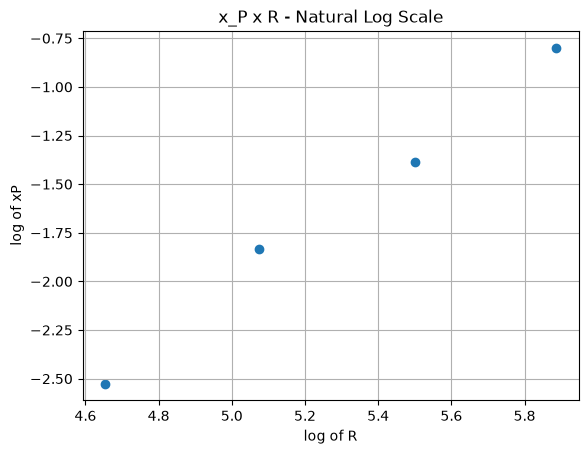

In [7]:
# plot the data
plt.scatter(x=data['log_R'], y=data['log_x_P'])
plt.xlabel('log of R')
plt.ylabel('log of xP')
plt.title('x_P x R - Natural Log Scale')
plt.grid()
plt.show()

In [8]:
# calculating the fit
line = LinearRegression().fit(X=data[['log_R']], y=data[['log_x_P']])

# coefficients and performance (coefficient of determination)
print('Coefficients: ', line.coef_)
print('Intercept:', line.intercept_)
print('R^2: %.4f'%line.score(X=data[['log_R']], y=data[['log_x_P']]))

Coefficients:  [[1.36454574]]
Intercept: [-8.83938436]
R^2: 0.9931


This is the expression that relates the $x_P$ to the $R$

$$log{x_P} = 1.364log_{R} - 8.84$$

/home/izelioli/.cache/pypoetry/virtualenvs/solving-chemical-engineering-problems-S1IOO9Yv-py3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


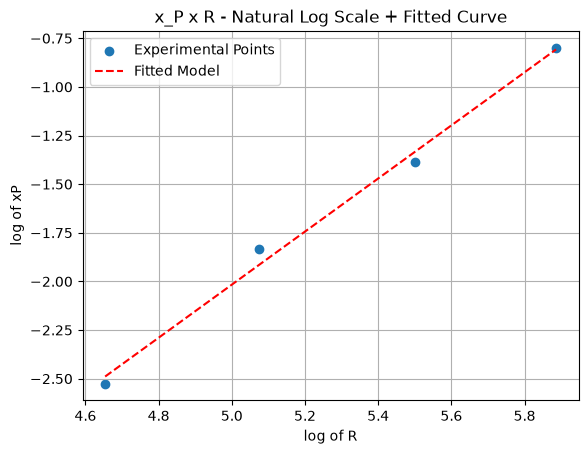

In [9]:
# plot the data with smoother grid
smooth_x = np.linspace(data['log_R'].min(), data['log_R'].max(), 100)
smooth_y = line.predict(smooth_x.reshape(-1,1))

plt.scatter(x=data['log_R'], y=data['log_x_P'], label='Experimental Points')
plt.plot(smooth_x, smooth_y, ls='--', color='red', label='Fitted Model')
plt.xlabel('log of R')
plt.ylabel('log of xP')
plt.title('x_P x R - Natural Log Scale + Fitted Curve')
plt.legend()
plt.grid()
plt.show()

In [10]:
# calculate fractions in each stream
R = [388, 583, 140]

def convert_R_to_xp(R):
    # calculate all log R
    logR = [np.log(r) for r in R]

    # predict log x_P
    log_x_p = line.predict(np.array(logR).reshape(-1, 1))

    # return to x_P
    x_P = np.exp(log_x_p)

    return x_P

x_P = convert_R_to_xp(R)

/home/izelioli/.cache/pypoetry/virtualenvs/solving-chemical-engineering-problems-S1IOO9Yv-py3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [11]:
# solve the purification process
factory = StreamFactory(
    component_names=['P', 'notP'],
    default_flow_type='kg'
)
factory.add_stream('ReactorEffluent', [x_P[0][0], None], flow_rate=2253)
factory.add_stream('PurifiedP', [x_P[1][0], None], flow_rate=1239, direction='output')
factory.add_stream('Waste', [x_P[2][0], None], direction='output')

# create and analyse process unit
purification = factory.build_process_unit('PurificationUnit')

# calculate material balances
purification.report_degrees_of_freedom()
# The recorded stream analyses and measured stream masses should reconcile.
try:
    purification.solve_material_balances()
except ValueError as error:
    print(f"The run-sheet data are inconsistent: {error}")



Degrees of Freedom Analysis for 'PurificationUnit':
  Unknown input fields (flows + fractions): 1
    - Stream 'Waste': flow rate
  Component-flow variables (mass basis): 6
    1. Stream 'ReactorEffluent': 'P'
    2. Stream 'ReactorEffluent': 'notP'
    3. Stream 'PurifiedP': 'P'
    4. Stream 'PurifiedP': 'notP'
    5. Stream 'Waste': 'P'
    6. Stream 'Waste': 'notP'
  Independent constraint rank: 6
    1. material balance for P
    2. material balance for notP
    3. total flow for ReactorEffluent
    4. P mass fraction for ReactorEffluent
    5. total flow for PurifiedP
    6. P mass fraction for PurifiedP
  Structural degrees of freedom: 0
  Status: STRUCTURALLY DETERMINED (feasibility is checked when solving)
The run-sheet data are inconsistent: Failed to solve material balances for 'PurificationUnit': constraints are infeasible with nonnegative component flows.


In [12]:
# scenario 1 - reactor effluent analysis error
def analyze_scenario(scenario_no: int):
    # scenario definitions
    definitions = {
        1: {
            'given': x_P[0][0],
            'stream': 'ReactorEffluent',
        },
        2: {
            'given': x_P[1][0],
            'stream': 'PurifiedP',
        },
        3: {
            'given': x_P[2][0],
            'stream': 'Waste',
        }
    }

    # list of streams
    streams = ['ReactorEffluent', 'PurifiedP', 'Waste']

    # select stream scenario and given lab values
    stream_scenario = definitions.get(scenario_no).get('stream')
    given_lab = definitions.get(scenario_no).get('given')

    # create factory
    factory = StreamFactory(
        component_names=['P', 'notP'],
        default_flow_type='kg'
    )

    # add streams according to scenario
    if scenario_no == 1:
        factory.add_stream('ReactorEffluent', [None, None], flow_rate=2253)
        factory.add_stream('PurifiedP', [x_P[1][0], None], flow_rate=1239, direction='output')
        factory.add_stream('Waste', [x_P[2][0], None], direction='output')
    elif scenario_no == 2:
        factory.add_stream('ReactorEffluent', [x_P[0][0], None], flow_rate=2253)
        factory.add_stream('PurifiedP', [None, None], flow_rate=1239, direction='output')
        factory.add_stream('Waste', [x_P[2][0], None], direction='output')
    else:
        factory.add_stream('ReactorEffluent', [x_P[0][0], None], flow_rate=2253)
        factory.add_stream('PurifiedP', [x_P[1][0], None], flow_rate=1239, direction='output')
        factory.add_stream('Waste', [None, None], direction='output')

    # add ratio restriction
    
    # create and analyse process unit
    purification = factory.build_process_unit('PurificationUnit')

    # calculate material balances
    purification.report_degrees_of_freedom()

    # solve material balances
    table = purification.solve_material_balances()
    purification.print_report()

    # calculate lab error
    real = table.loc[('mass_fraction', 'P'), stream_scenario]
    print('Lab Data for Stream %s: %.4f'%(stream_scenario, given_lab))
    print('Real Data - Material Balance: %.4f'%real)
    print('Lab Error: %.2f%%'%((real-given_lab)*100/given_lab))

    del factory


In [13]:
# analyze all scenarios
for i in range(1, 4):
    print('Analyzing Scenario %d'%i)
    analyze_scenario(i)
    print('-'*100)


Analyzing Scenario 1

Degrees of Freedom Analysis for 'PurificationUnit':
  Unknown input fields (flows + fractions): 3
    - Stream 'ReactorEffluent': mass fraction of 'P'
    - Stream 'ReactorEffluent': mass fraction of 'notP'
    - Stream 'Waste': flow rate
  Component-flow variables (mass basis): 6
    1. Stream 'ReactorEffluent': 'P'
    2. Stream 'ReactorEffluent': 'notP'
    3. Stream 'PurifiedP': 'P'
    4. Stream 'PurifiedP': 'notP'
    5. Stream 'Waste': 'P'
    6. Stream 'Waste': 'notP'
  Independent constraint rank: 6
    1. material balance for P
    2. material balance for notP
    3. total flow for ReactorEffluent
    4. total flow for PurifiedP
    5. P mass fraction for PurifiedP
    6. P mass fraction for Waste
  Structural degrees of freedom: 0
  Status: STRUCTURALLY DETERMINED (feasibility is checked when solving)

Process unit report: PurificationUnit
Material balance basis: mass
Molar-basis results unavailable for streams containing: P, notP (molar mass not suppli

## Problem 4.34 — Indicator-Dilution Method

The **indicator-dilution method** is a technique used to determine flow rates of fluids in channels for which devices like rotameters and orifice meters cannot be used, such as rivers, blood vessels, and large-diameter pipelines.

A stream of an easily measured substance, called a **tracer**, is injected into the channel at a known rate, and the tracer concentration is measured at a point far enough downstream of the injection point for the tracer to be completely mixed with the flowing fluid.

The larger the flow rate of the fluid, the lower the tracer concentration at the measurement point.

A gas stream that contains **1.50 mole% CO₂** flows through a pipeline. **20.0 kg of CO₂ per minute** is injected into the line.

A sample of the gas is drawn from a point in the line **150 m downstream** of the injection point and is found to contain **2.3 mole% CO₂**.

### (a)

Estimate the gas flow rate, in **kmol/min**, upstream of the injection point.

### (b)

**18 s** elapse from the instant the additional CO₂ is first injected to the time the CO₂ concentration at the measurement point begins to rise.

Assuming that the tracer travels at the average velocity of the gas in the pipeline, i.e. neglecting diffusion of CO₂:

1. Estimate the average gas velocity in **m/s**.
2. If the molar gas density is

$$
0.123\ \text{kmol/m}^3,
$$

estimate the **pipe diameter**.

In [14]:
# constants
yco2in = 0.015 # initial molar CO2 composition of input stream
yco2out = 0.023 # molar CO2 composition of output stream
mCO2in = 20 # mass flow rate of CO2 trace injected (kg/min)

# solve the mixer
factory = StreamFactory(
    component_names=['CO2', 'others'],
    default_flow_type='kmol/min',
    molar_masses=[44.01, None]
)

# add streams
factory.add_stream('CarryGas', compositions=[yco2in, 1-yco2in],composition_basis='molar')
factory.add_stream('Trace', compositions=[1,0], flow_rate=20, flow_type='kg/min',composition_basis='mass')
factory.add_stream('Mixture',compositions=[yco2out, 1-yco2out], direction='output', composition_basis='molar')

# build process unit
mixer = factory.build_process_unit('Mixer')

# analyze dof
mixer.report_degrees_of_freedom()


Degrees of Freedom Analysis for 'Mixer':
  Unknown input fields (flows + fractions): 2
    - Stream 'CarryGas': flow rate
    - Stream 'Mixture': flow rate
  Component-flow variables (molar basis): 6
    1. Stream 'CarryGas': 'CO2'
    2. Stream 'CarryGas': 'others'
    3. Stream 'Trace': 'CO2'
    4. Stream 'Trace': 'others'
    5. Stream 'Mixture': 'CO2'
    6. Stream 'Mixture': 'others'
  Independent constraint rank: 6
    1. material balance for CO2
    2. material balance for others
    3. CO2 molar fraction for CarryGas
    4. total flow for Trace
    5. zero flow for others in Trace
    6. CO2 molar fraction for Mixture
  Structural degrees of freedom: 0
  Status: STRUCTURALLY DETERMINED (feasibility is checked when solving)


In [15]:
# calculate the material balances
table = mixer.solve_material_balances()
table

CarryGas      Trace    Mixture
variable                  component                                 
mass_flow_rate                             NaN  20.000000        NaN
molar_flow_rate                      55.498750   0.454442  55.953192
component_mass_flow_rate  CO2              NaN  20.000000        NaN
                          others           NaN   0.000000        NaN
component_molar_flow_rate CO2         0.832481   0.454442   1.286923
                          others     54.666269   0.000000  54.666269
mass_fraction             CO2              NaN   1.000000        NaN
                          others           NaN   0.000000        NaN
mole_fraction             CO2         0.015000   1.000000   0.023000
                          others      0.985000   0.000000   0.977000

## Problem 4.43 — Orange Juice Concentration with Bypass

The popularity of orange juice, especially as a breakfast drink, makes this beverage an important factor in the economy of orange-growing regions. Most marketed juice is concentrated and frozen and then reconstituted before consumption, and some is “not-from-concentrate.”

The approaches to concentrating orange juice include evaporation, freeze concentration, and reverse osmosis. Here, consider the evaporation process and focus only on two constituents in the juice: **solids** and **water**.

Fresh orange juice contains approximately **10 wt% solids** and frozen concentrate contains approximately **42 wt% solids**.

The frozen concentrate is obtained by evaporating water from the fresh juice to produce a mixture that is approximately **65 wt% solids**. However, so that the flavor of the concentrate will closely approximate that of fresh juice, the concentrate from the evaporator is blended with fresh orange juice to produce a final concentrate that is approximately **42 wt% solids**.

### (a)

Draw and label a flowchart of this process, neglecting the vaporization of everything in the juice except water.

First, prove that the subsystem containing the point where the **bypass stream** splits off from the evaporator feed has **one degree of freedom**.

Then perform the degree-of-freedom analysis for:

- the overall system;
- the evaporator; and
- the bypass–evaporator product mixing point.

Write, in order, the equations you would solve to determine all unknown stream variables.

In each equation, identify the variable for which you would solve, but **do not perform the calculations**.

### (b)

Calculate:

1. the amount of **42 wt% concentrate** produced per **100 kg of fresh juice** fed to the process; and
2. the fraction of the feed that **bypasses the evaporator**.